Importing the Dependencies

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

Loading the Dataset

In [2]:
# Load the dataset into Pandas dataframe
df = pd.read_csv(r'C:\Users\Vikram\OneDrive\Desktop\Internships\Internship Projects\Future Interns\Task-1.1 Online Retail dataset.csv')

In [3]:
# First 5 rows of the dataframe
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Total number of rows and columns
df.shape

(541909, 8)

In [5]:
# Basic information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
# Statistical description of numerical coumns
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Data Preprocessing

In [7]:
# Checking for mising values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# Removing all the rows which has null values in 'Description' column
df = df.dropna(subset=['Description'])

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [10]:
# Creating a new 'Revenue' column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [11]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [12]:
# Checking for duplicate values
df.duplicated().sum()

np.int64(5268)

In [13]:
# Removing duplicate rows
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(535187, 9)

Data Analysis

In [16]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Que - Which products generate the most revenue?

In [17]:
max_revenue = df.groupby('Revenue')['Description'].value_counts().sort_index(ascending=False).reset_index().head(20)
max_revenue = pd.DataFrame(max_revenue)

In [18]:
max_revenue.head()

,Revenue,Description,count
0,168469.60,"PAPER CRAFT , LITTLE BIRDIE",1
1,77183.60,MEDIUM CERAMIC TOP STORAGE JAR,1
2,38970.00,PICNIC BASKET WICKER 60 PIECES,1
3,13541.33,AMAZON FEE,1
4,11062.06,Adjust bad debt,1


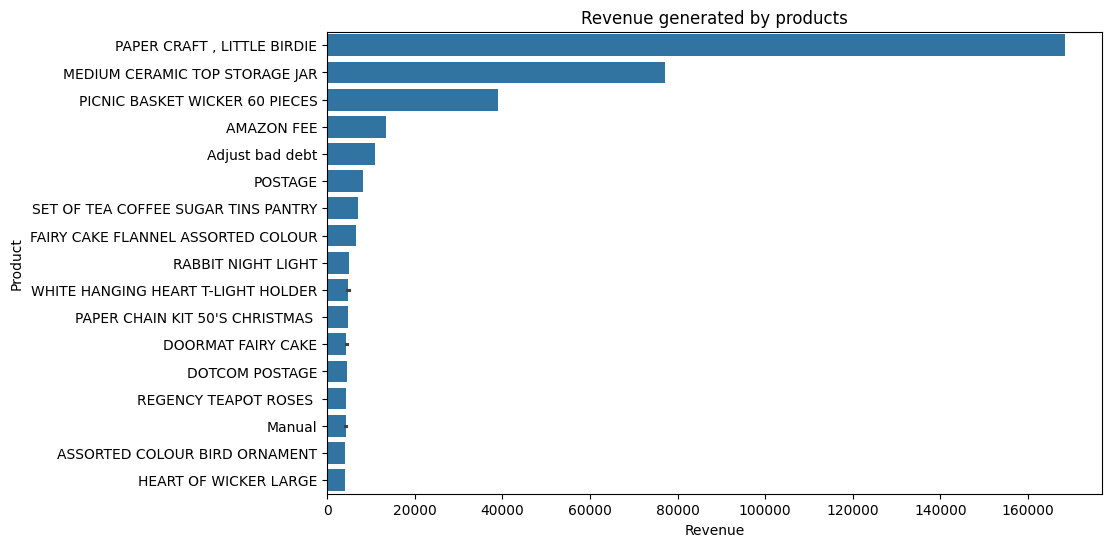

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(y=max_revenue.Description, x=max_revenue['Revenue'], data=max_revenue)
plt.title('Revenue generated by products')
plt.ylabel('Product')
plt.xlabel('Revenue')

# plt.xticks(rotation=90)
plt.show()

**Conclusion:** Paper Craft, Little Birdie generated the maximum revenue.

Que - How do sales change over time?

In [20]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
# Converting dtype of 'InvoiceDate' into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [23]:
# Extract year-month
df['Date'] = df['InvoiceDate'].dt.strftime('%Y-%m')

In [24]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [25]:
sales = df.groupby('Date')['Revenue'].sum()
sales

Date
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     681386.460
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Name: Revenue, dtype: float64

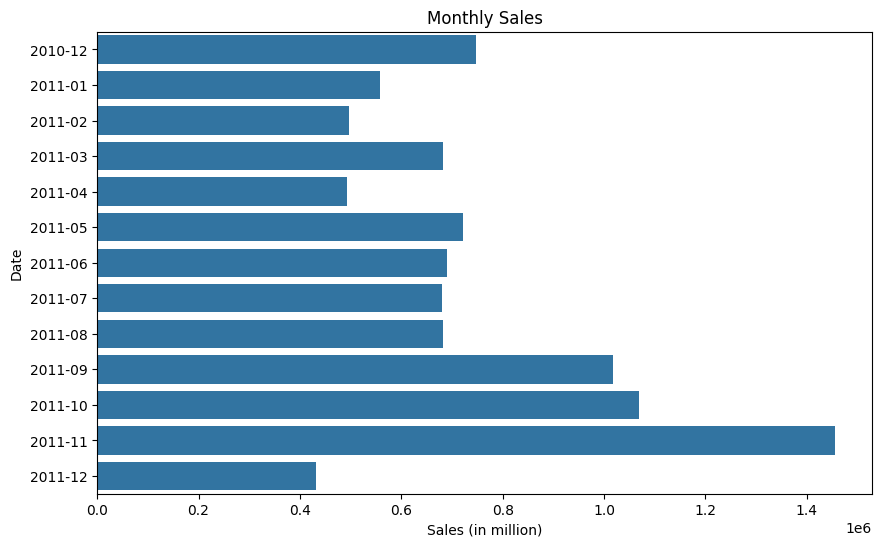

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x=sales.values, y=sales.index)
plt.title('Monthly Sales')
plt.xlabel('Sales (in million)')
plt.ylabel('Date')

plt.show()

Which categories or regions are most profitable?

In [27]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [28]:
categories_profit = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).reset_index().head(10)
categories_profit

,Description,Revenue
0,DOTCOM POSTAGE,206245.48
1,REGENCY CAKESTAND 3 TIER,164459.49
2,WHITE HANGING HEART T-LIGHT HOLDER,99612.42
3,PARTY BUNTING,98243.88
4,JUMBO BAG RED RETROSPOT,92175.79
5,RABBIT NIGHT LIGHT,66661.63
6,POSTAGE,66230.64
7,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
8,ASSORTED COLOUR BIRD ORNAMENT,58792.42
9,CHILLI LIGHTS,53746.66


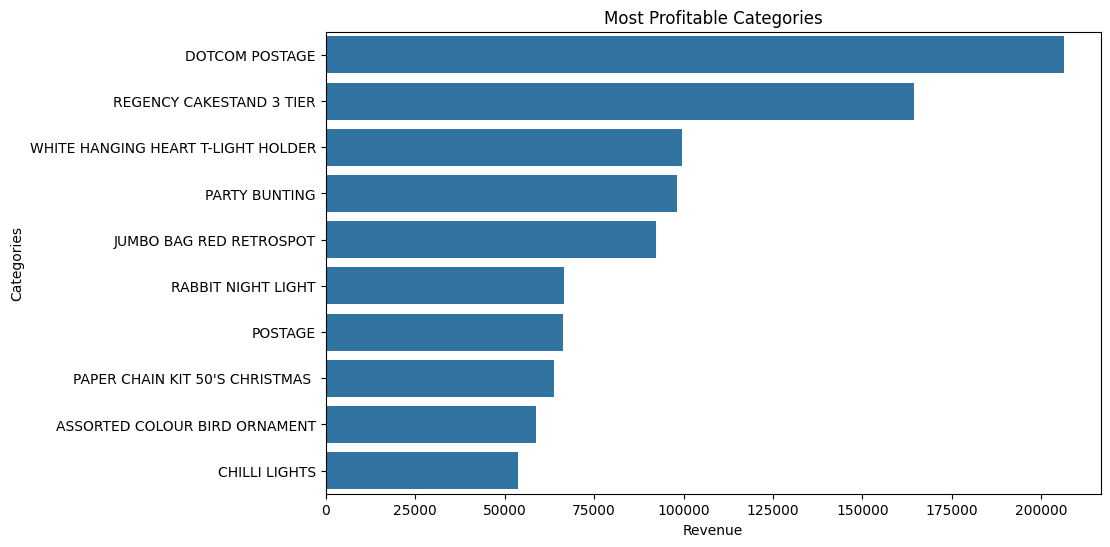

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x=categories_profit['Revenue'], y=categories_profit['Description'], data=categories_profit)
plt.title('Most Profitable Categories')
plt.xlabel('Revenue')
plt.ylabel('Categories')

plt.show()

Dotcom Postage generates the maximum revenue.

In [30]:
country_profit = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).reset_index().head(10)
country_profit

,Country,Revenue
0,United Kingdom,8167128.184
1,Netherlands,284661.540
2,EIRE,262993.380
3,Germany,221509.470
4,France,197317.110
5,Australia,137009.770
6,Switzerland,56363.050
7,Spain,54756.030
8,Belgium,40910.960
9,Sweden,36585.410


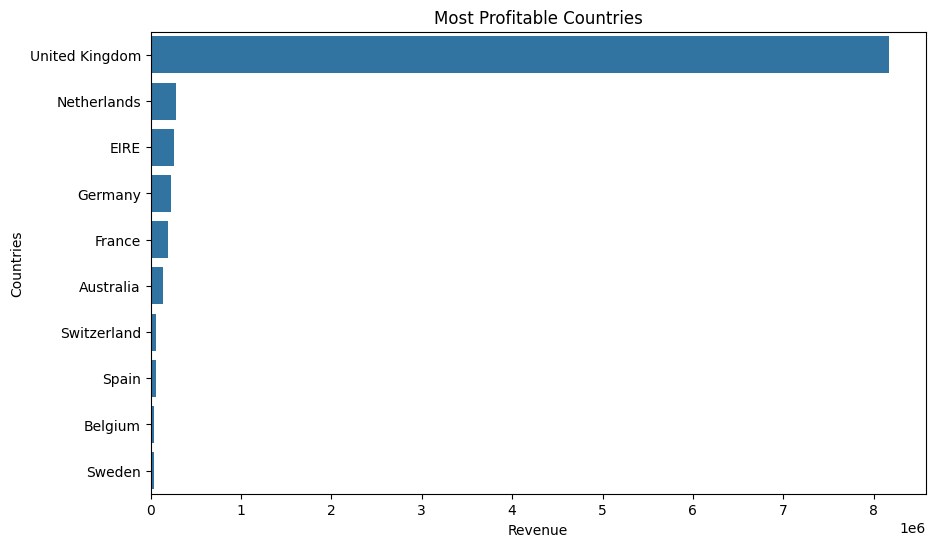

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x=country_profit['Revenue'], y=country_profit['Country'], data=country_profit)
plt.title('Most Profitable Countries')
plt.xlabel('Revenue')
plt.ylabel('Countries')

plt.show()

United Kingdom earns the most revenue.

Que - Where should business focus to grow faster?

In [32]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12


In [33]:
least_profit = df.groupby('Country')['Revenue'].sum().sort_values(ascending=True).reset_index().head(10)
least_profit

,Country,Revenue
0,Saudi Arabia,131.17
1,Bahrain,548.40
2,Czech Republic,707.72
3,RSA,1002.31
4,Brazil,1143.60
5,European Community,1291.75
6,Lithuania,1661.06
7,Lebanon,1693.88
8,USA,1730.92
9,United Arab Emirates,1902.28


In [34]:
least_categories_profit = df.groupby('Description')['Revenue'].sum().sort_values(ascending=True).reset_index().head(10)
least_categories_profit

,Description,Revenue
0,AMAZON FEE,-221520.500
1,Manual,-69031.640
2,Adjust bad debt,-11062.060
3,CRUK Commission,-7933.430
4,Bank Charges,-7175.639
5,Discount,-5696.220
6,SAMPLES,-3039.650
7,WHITE CHERRY LIGHTS,-54.000
8,CREAM SWEETHEART MAGAZINE RACK,-46.850
9,WOODEN BOX ADVENT CALENDAR,-45.700


**CONCLUSION:** Business should focus on the following points to grow faster:
- Business should try to sell more of those products which already generates maximum amount of revenue. eg. - **DOTCOM POSTAGE, REGENCY CAKESTAND 3 TIER, WHITE HANGING HEART T-LIGHT HOLDER**
- Business should also try to sell more of those products which generate slightly lesser revenue. For this it should try to market those products better to the potential customers.
- It should try to open its more branches/outlets in most profitable countries like - **UK, Netherlands, EIRE, Germany.**
- It should get out of business from those countries that are either generating heavy losses or very less profits to the business, like - **Saudi Arabia, Bahrain, Czech Republic** etc.
- It should remove those products from the business that are generating losses to the business. eg. - **WHITE CHERRY LIGHTS, CREAM SWEETHEART MAGAZINE RACK, WOODEN BOX ADVENT CALENDAR**
- It should try to cut its unnecessary expenses which reduces overall profits of the business. eg. - **AMAZON FEE, Manual, Adjust bad debt, CRUK Commission, Bank Charges.**